#***EXPLORATORY DATA ANALYSIS***

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [ ]:
Netflix_df = pd.read_csv('/content/drive/MyDrive/ML end-to-end project /Unsupervised ML Project/NETFLIX MOVIES AND TV SHOWS CLUSTERING.csv', encoding = 'latin1')
Netflix_df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,TV Show,3%,NaN,"JoÃ£o Miguel, Bianca Comparato, Michel Gomes, ...",Brazil,"August 14, 2020",2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s2,Movie,7:19,Jorge Michel Grau,"DemiÃ¡n Bichir, HÃ©ctor Bonilla, Oscar Serrano...",Mexico,"December 23, 2016",2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",2011,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow..."
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",2009,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi..."
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",2008,PG-13,123 min,Dramas,A brilliant group of students become card-coun...


In [ ]:
Netflix_df.shape

(7787, 12)

In [ ]:
Netflix_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7787 entries, 0 to 7786
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       7787 non-null   object
 1   type          7787 non-null   object
 2   title         7787 non-null   object
 3   director      5398 non-null   object
 4   cast          7069 non-null   object
 5   country       7280 non-null   object
 6   date_added    7777 non-null   object
 7   release_year  7787 non-null   int64 
 8   rating        7780 non-null   object
 9   duration      7787 non-null   object
 10  listed_in     7787 non-null   object
 11  description   7787 non-null   object
dtypes: int64(1), object(11)
memory usage: 730.2+ KB


In [ ]:
Netflix_df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2389
cast,718
country,507
date_added,10
release_year,0
rating,7
duration,0


In [ ]:
Netflix_df.describe()

,release_year
count,7787.000000
mean,2013.932580
std,8.757395
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2018.000000
max,2021.000000


In [ ]:
Netflix_df.duplicated().sum()

np.int64(0)

In [ ]:
Netflix_df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

**Feature Selection**

In [ ]:
#Dropping Unwanted features
Netflix_data = Netflix_df.drop(['show_id', 'title', 'director', 'cast'], axis = 1)
Netflix_data.head()

,type,country,date_added,release_year,rating,duration,listed_in,description
0,TV Show,Brazil,"August 14, 2020",2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,Movie,Mexico,"December 23, 2016",2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...
2,Movie,Singapore,"December 20, 2018",2011,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow..."
3,Movie,United States,"November 16, 2017",2009,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi..."
4,Movie,United States,"January 1, 2020",2008,PG-13,123 min,Dramas,A brilliant group of students become card-coun...


**Feature Manipulation & Engineering**

In [ ]:
#Modifying date added column
Netflix_data['date_added'] = Netflix_data['date_added'].str.strip()
Netflix_data['date_added'] = pd.to_datetime(Netflix_data['date_added'])
Netflix_data['year_added'] = Netflix_data['date_added'].dt.year
Netflix_data['month_added'] = Netflix_data['date_added'].dt.month

In [ ]:
Netflix_data['duration'] = Netflix_data['duration'].str.strip()
Netflix_data['duration'] = Netflix_data['duration'].str.replace(' min', '')
Netflix_data['duration'] = Netflix_data['duration'].str.replace(' Seasons', '')
Netflix_data['duration'] = Netflix_data['duration'].str.replace(' Season', '')
Netflix_data['duration'] = Netflix_data['duration'].astype(int)

In [ ]:
Netflix_data.head()

,type,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added
0,TV Show,Brazil,2020-08-14,2020,TV-MA,4,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...,2020.0,8.0
1,Movie,Mexico,2016-12-23,2016,TV-MA,93,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...,2016.0,12.0
2,Movie,Singapore,2018-12-20,2011,R,78,"Horror Movies, International Movies","When an army recruit is found dead, his fellow...",2018.0,12.0
3,Movie,United States,2017-11-16,2009,PG-13,80,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi...",2017.0,11.0
4,Movie,United States,2020-01-01,2008,PG-13,123,Dramas,A brilliant group of students become card-coun...,2020.0,1.0


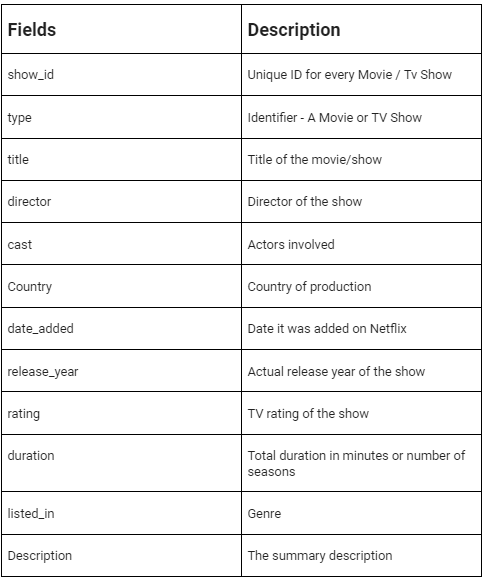

In [ ]:
Netflix_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7787 entries, 0 to 7786
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   type          7787 non-null   object        
 1   country       7280 non-null   object        
 2   date_added    7777 non-null   datetime64[ns]
 3   release_year  7787 non-null   int64         
 4   rating        7780 non-null   object        
 5   duration      7787 non-null   int64         
 6   listed_in     7787 non-null   object        
 7   description   7787 non-null   object        
 8   year_added    7777 non-null   float64       
 9   month_added   7777 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(2), object(5)
memory usage: 608.5+ KB


Goal - To Perform clustering using Netflix Dataset and the aim is to identify patterns or similarities  

Analysis :
1. Movies vs TV Shows (Understanding how many movies & TV shows are present on the Netflix)
2. Country vs Movies/TV Shows here also find count of movies & tv shows for each country
3. Movies/TV Shows vs Release year (Find out how many movies were released in a particular year)
4. Duration vs Movie/TV Shows (Find out the count of movies in a particular duration)
5. Rating vs Movie/TV Shows
6. Duration vs Rating
7. Listed_in(Genre) vs Movie/TV Shows counts
8. Country vs Duration (Finding out average duration according to country)
9. Country vs Listed_in(Genre) ( Find out which countries prefer which genres)
10. Distribution of Duration(Movies) & Distribution of Duration(TV Shows)
11. Listed_in(Genre) Vs Rating
12. Year_added vs Movie & Tv Shows
13. Month_added vs Movie & TV Shows
14. Country vs Rating
This analysis is done for understanding relationship between all the variables

**Visualizations**

##**Univariate Analysis**

 ### Chart 1

In [ ]:
fig = px.histogram(Netflix_data, x = 'type', title = 'Movies vs TV Show Distribution')
fig.update_layout(
    xaxis_title="Type",
    yaxis_title="Count"
)
fig.show()

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

##**Bivariate Analysis**

In [ ]:
top_10_countries = Netflix_data['country'].value_counts().head(10).index
df_top = Netflix_data[Netflix_data['country'].isin(top_10_countries)]

fig = px.histogram (
    df_top,
    y ='country',
    color = 'type',
    title='Top 10 Countries with Most Movies & TV Shows',
    category_orders = {"country" : top_10_countries} #ensures descending order
    )
fig.update_layout(
    xaxis_title="Count",
    yaxis_title="Country"
)
fig.show()

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

In [ ]:
year_counts = Netflix_data['release_year'].value_counts().sort_index()

fig = px.line(x=year_counts.index, y=year_counts.values,
              labels={'x':'Release Year','y':'Count'},
              title='Content Released Per Year')
fig.show()

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

In [ ]:
fig = px.box(
    Netflix_data,
    x='type',
    y='duration',
    title='Distribution of Duration by Content type',
    )
fig.update_layout(
    xaxis_title="Type",
    yaxis_title="Duration"
)
fig.show()

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

In [ ]:
fig = px.histogram(
    Netflix_data,
    x='rating',
    color='type',
    title='Rating vs Content Type')
fig.update_layout(
    xaxis_title="Rating",
    yaxis_title="Count"
)
fig.show()

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

In [ ]:
fig = px.box(
    Netflix_data,
    x='rating',
    y='duration',
    title='Duration vs Rating')
fig.update_layout(
    xaxis_title="Rating",
    yaxis_title="Duration"
)
fig.show()

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

In [ ]:
Netflix_data['main_genre'] = Netflix_data['listed_in'].apply(lambda x: x.split(',')[0])
fig = px.histogram(
    Netflix_data,
    y='main_genre',
    color = 'type',
    title='Genre vs Content Type')

fig.update_layout(
    xaxis_title="Count",
    yaxis_title="Genre",
    height = 800
)

fig.show()

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

In [ ]:
from pandas.core.indexes import category
movies = Netflix_data[Netflix_data['type'] == 'Movie']
top_10_countries_movies = movies['country'].value_counts().head(10).index
movies_top = movies[movies['country'].isin(top_10_countries_movies)]
fig = px.histogram(
    movies_top,
    x='country',
    y='duration',
    title='Average Movie Duration by Country(Top 10)',
    histfunc='avg',
    category_orders = {'country' : top_10_countries_movies}
)

fig.update_layout(
    xaxis_title="Country",
    yaxis_title="Avg of Duration",
)

fig.show()

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

In [ ]:
TV_Shows = Netflix_data[Netflix_data['type'] == 'TV Show']
top_10_countries_tvshows = TV_Shows['country'].value_counts().head(10).index
TV_Shows_top = TV_Shows[TV_Shows['country'].isin(top_10_countries_tvshows)]
fig = px.histogram(
    TV_Shows_top,
    x = 'country',
    y = 'duration',
    title='Average Movie TV Show Duration by Country(Top 10)',
    histfunc='avg',
    category_orders = {'country' : top_10_countries_tvshows}
)

fig.update_layout(
    xaxis_title="Country",
    yaxis_title="Avg of Duration"
)

fig.show()

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

In [ ]:
fig = px.histogram(
    Netflix_data,
    x='main_genre',
    color='rating',
    title='Genre vs Rating')
fig.update_layout(
    xaxis_title="Genre",
    yaxis_title="Count"
)
fig.show()

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

In [ ]:
import plotly.figure_factory as ff

data = [movies['duration']]
labels = ['Movie Duration']

fig = ff.create_distplot(
    data,
    labels,
    show_hist=True,
    show_rug=False
)

fig.update_layout(
    title="Movie Duration Distribution with KDE",
    xaxis_title="Duration (minutes)",
    yaxis_title="Density"
)

fig.show()

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

In [ ]:
data = [TV_Shows['duration']]
labels = ['TV Show Duration']

fig = ff.create_distplot(
    data,
    labels,
    show_hist=True,
    show_rug=False
)

fig.update_layout(
    title="TV Show Duration Distribution with KDE",
    xaxis_title="Duration (No. of Seasons)",
    yaxis_title="Density"
)

fig.show()

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

In [ ]:
fig = px.histogram(
    Netflix_data,
    x = 'year_added',
    color = 'type',
    title='Year Added vs Content Type')

fig.update_layout(
    xaxis_title="Year",
    yaxis_title="Count"
)

fig.show()

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

In [ ]:
Netflix_data.head()

,type,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added,main_genre
0,TV Show,Brazil,2020-08-14,2020,TV-MA,4,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...,2020.0,8.0,International TV Shows
1,Movie,Mexico,2016-12-23,2016,TV-MA,93,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...,2016.0,12.0,Dramas
2,Movie,Singapore,2018-12-20,2011,R,78,"Horror Movies, International Movies","When an army recruit is found dead, his fellow...",2018.0,12.0,Horror Movies
3,Movie,United States,2017-11-16,2009,PG-13,80,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi...",2017.0,11.0,Action & Adventure
4,Movie,United States,2020-01-01,2008,PG-13,123,Dramas,A brilliant group of students become card-coun...,2020.0,1.0,Dramas


In [ ]:
fig = px.histogram(
    Netflix_data,
    x = 'month_added',
    color = 'type',
    title='Month Added vs Content Type')

fig.update_layout(
    xaxis_title="Month",
    yaxis_title="Count",
    width = 1000
)

fig.show()

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

In [ ]:
fig = px.histogram (
    df_top,
    x ='country',
    color = 'rating',
    title='Top 10 Countries with distribution of ratings',
    category_orders = {"country" : top_10_countries} #ensures descending order
    )
fig.update_layout(
    xaxis_title="Country",
    yaxis_title="Count"
)
fig.show()

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

In [ ]:
Netflix_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7787 entries, 0 to 7786
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   type          7787 non-null   object        
 1   country       7280 non-null   object        
 2   date_added    7777 non-null   datetime64[ns]
 3   release_year  7787 non-null   int64         
 4   rating        7780 non-null   object        
 5   duration      7787 non-null   int64         
 6   listed_in     7787 non-null   object        
 7   description   7787 non-null   object        
 8   year_added    7777 non-null   float64       
 9   month_added   7777 non-null   float64       
 10  main_genre    7787 non-null   object        
dtypes: datetime64[ns](1), float64(2), int64(2), object(6)
memory usage: 669.3+ KB


## **Multivariate Analysis**

In [ ]:
corr = Netflix_data[['release_year', 'duration', 'year_added', 'month_added']].corr()

fig = ff.create_annotated_heatmap(
    z=corr.values,
    x=list(corr.columns),
    y=list(corr.index),
    annotation_text=corr.round(2).values,
    colorscale='Viridis'
)

fig.update_layout(title='Correlation Heatmap')
fig.show()


##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here